<a href="https://colab.research.google.com/github/RuiRodrigues-lab/DataScienceFE/blob/Locker/CP4_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
#Precisamos desta biblioteca para podermos escolher um ficheiro local
#Se o ficheiro vier por API ou tivermos um link, é so alterar a forma de import
from google.colab import files

# 1️⃣ Faz upload do ficheiro (vai abrir uma janela para escolher no teu PC)
uploaded = files.upload()

# 2️⃣ Guarda o nome do ficheiro (Colab mostra o nome depois do upload)
filename = list(uploaded.keys())[0]

# 3️⃣ Lê o Excel, por default lê sempre a primeira tab, por isso podemos usar o "sheet_name"
# Se tivermos dados em varias tabs, devemos usar uma Dataframe(df) para cada uma das tabs
df = pd.read_excel(filename, sheet_name='Exerc6')
df.head()

Saving CP4_6.xlsx to CP4_6 (4).xlsx


,Envolvimento,Absentismo
0,Nem_muito_nem_pouco,2
1,Pouco_envolvido,4
2,Envolvido,1
3,Muito_pouco_envolvido,5
4,Muito_envolvido,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Envolvimento  50 non-null     object
 1   Absentismo    50 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 932.0+ bytes


In [29]:
#Todas as qualitativas devem ser ordenadas, mesmo nominais

envolvimento_type = CategoricalDtype(
    categories=["Nada_envolvido", "Muito_pouco_envolvido", "Pouco_envolvido", "Nem_muito_nem_pouco", "Envolvido", "Muito_envolvido", "Completamente_envolvido"],
    ordered=True
)

df['Envolvimento'] = df['Envolvimento'].astype(envolvimento_type)

#Para vermos se ficou tudo bem, definimos esta função, sempre que temos ordinais, temos de fazer isto
def glimpse(df):
    print(f"📊 DataFrame com {df.shape[0]} linhas e {df.shape[1]} colunas\n")
    for col in df.columns:
        dtype = df[col].dtype
        preview = df[col].unique()[:5]  # mostra até 5 valores únicos
        print(f"{col:<15} ({dtype})  →  {preview}")

#print
glimpse(df)


📊 DataFrame com 50 linhas e 2 colunas

Envolvimento    (category)  →  ['Nem_muito_nem_pouco', 'Pouco_envolvido', 'Envolvido', 'Muito_pouco_envolvido', 'Muito_envolvido']
Categories (7, object): ['Nada_envolvido' < 'Muito_pouco_envolvido' < 'Pouco_envolvido' <
                         'Nem_muito_nem_pouco' < 'Envolvido' < 'Muito_envolvido' <
                         'Completamente_envolvido']
Absentismo      (int64)  →  [2 4 1 5 0]


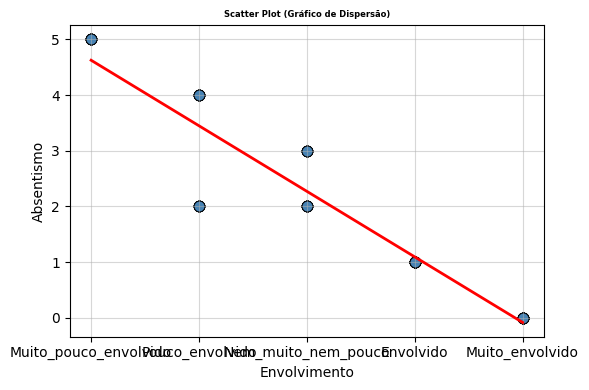

Coeficiente angular (b1): -1.18
Intercepto (b0): 5.80
Correlação de Pearson:  -0.937095
Correlação de Spearman: -0.951839


In [39]:
# 🔹 Gráfico de dispersão (equivalente a plot())
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x="Envolvimento", y="Absentismo",
    data=df, color="steelblue", s=60, edgecolor="black"
)

# Convert the ordinal 'Envolvimento' column to numerical values that match the order of the categories
df['Envolvimento_numerical'] = df['Envolvimento'].cat.codes

# 🔹 Regressão linear (equivalente a lm() + abline())
X = df[["Envolvimento_numerical"]]
y = df["Absentismo"]

model = LinearRegression()
model.fit(X, y)

# Gerar valores previstos. Use the numerical codes for the x-axis for plotting the line.
x_vals = np.linspace(df["Envolvimento_numerical"].min(), df["Envolvimento_numerical"].max(), 100)
y_vals = model.predict(pd.DataFrame(x_vals, columns=["Envolvimento_numerical"]))

# Plot the regression line using the numerical x_vals, which correspond to the positions of the categories on the plot
plt.plot(x_vals, y_vals, color="red", linewidth=2)


# 🔹 Melhorar o gráfico
plt.title("Scatter Plot (Gráfico de Dispersão)", fontsize=6, weight="bold")
plt.xlabel("Envolvimento")
plt.ylabel("Absentismo")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

# 🔹 Coeficientes (opcional)
print(f"Coeficiente angular (b1): {model.coef_[0]:.2f}")
print(f"Intercepto (b0): {model.intercept_:.2f}")

# 🔹 Correlação de Pearson (linear)
# Calculate Pearson correlation using the numerical representation
cor_pearson = df["Absentismo"].corr(df["Envolvimento_numerical"], method="pearson")

# 🔹 Correlação de Spearman (por postos)
cor_spearman = df["Absentismo"].corr(df["Envolvimento_numerical"], method="spearman")

print(f"Correlação de Pearson:  {cor_pearson:.6f}")
print(f"Correlação de Spearman: {cor_spearman:.6f}")